# Análisis Completo de Señales EMG desde Archivos CSV

Este notebook implementa un análisis exhaustivo de señales de electromiografía (EMG) registradas en formato CSV por equipos Noraxon.

## Contenido:
1. **Importación de librerías** - Configuración del entorno
2. **Configuración y funciones base** - Parámetros del filtrado
3. **Carga de datos** - Lectura de archivos CSV
4. **Procesamiento previo** - Eliminación de ruido y artefactos
5. **Características temporales** - Análisis en el dominio del tiempo
6. **Características espectrales** - Análisis en el dominio de la frecuencia
7. **Detección de fatiga** - Análisis de cambios espectrales
8. **Análisis completo y visualización** - Resumen e gráficos finales

**Aplicación:** Control de robots, detección de fatiga muscular, análisis de rendimiento físico.

## Sección 1: Importar Librerías Necesarias

Instalaremos y cargaremos todas las librerías que necesitamos para:
- **pandas**: Lectura y manipulación de archivos CSV
- **numpy**: Operaciones matemáticas y algebraicas
- **matplotlib**: Visualización de gráficos
- **scipy.signal**: Filtrado digital y análisis espectral

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, correlate
import os
from pathlib import Path

# Configurar matplotlib para mejor visualización
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print(" Todas las librerías cargadas correctamente")

 Todas las librerías cargadas correctamente


## Sección 2: Configuración Global y Funciones de Filtrado

### Parámetros de Configuración:

- **FS (Frecuencia de Muestreo)**: 2000 Hz - Estándar en equipos Noraxon
- **CUTOFF_LOW**: 20 Hz - Elimina artefactos de movimiento y ruido de baja frecuencia
- **CUTOFF_HIGH**: 450 Hz - Elimina ruido de alta frecuencia (aliasing)
- **ENVELOPE_CUTOFF**: 6 Hz - Suaviza la envolvente para obtener dinámica muscular
- **FATIGUE_THRESHOLD**: 0.9 (90%) - Umbral para detectar fatiga (si MDF baja más del 10%)

### Filtro Pasa Banda Butterworth:
Un filtro Butterworth de orden 4 preserva la forma de la señal sin distorsiones de fase (usando `filtfilt` que filtra en ambas direcciones).

In [2]:
# --- CONFIGURACIÓN GLOBAL ---
DEFAULT_FS = 2000  # Frecuencia de muestreo (Hz) - Estándar Noraxon
CUTOFF_LOW = 20    # Paso alto para eliminar artefactos de movimiento (Hz)
CUTOFF_HIGH = 450  # Paso bajo para eliminar ruido de alta frecuencia (Hz)
ENVELOPE_CUTOFF = 6  # Paso bajo para la envolvente - Dinámica muscular (Hz)
FATIGUE_THRESHOLD = 0.9  # 90% de MDF inicial = criterio de fatiga


def remove_dc_offset(data: np.ndarray) -> np.ndarray:
    """
    Elimina la componente DC (media) de la señal.
    
    La componente DC es el valor promedio de la señal.
    Al removerla, centramos la señal alrededor de cero.
    """
    return data - np.mean(data)


def butter_bandpass_filter(data: np.ndarray, lowcut: float, highcut: float, 
                           fs: int, order: int = 4) -> np.ndarray:
    """
    Aplica un filtro pasa banda Butterworth a la señal EMG.
    
    Pasos:
    1. Normalizar frecuencias respecto a la frecuencia de Nyquist (fs/2)
    2. Diseñar coeficientes del filtro Butterworth
    3. Aplicar filtfilt (filtrado bidireccional para preservar fase)
    
    Args:
        data: Señal de entrada (array de numpy)
        lowcut: Frecuencia de corte baja (Hz) - Típicamente 20 Hz
        highcut: Frecuencia de corte alta (Hz) - Típicamente 450 Hz
        fs: Frecuencia de muestreo (Hz) - Típicamente 2000 Hz
        order: Orden del filtro (4 es estándar para EMG)
    
    Returns:
        Señal filtrada en el rango 20-450 Hz
    """
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    low = lowcut / nyq  # Normalizar frecuencia baja
    high = highcut / nyq  # Normalizar frecuencia alta
    
    # Obtener coeficientes del filtro Butterworth
    b, a = butter(order, [low, high], btype='band')
    
    # Aplicar filtro en ambas direcciones (avanza y retrocede)
    # Esto elimina la distorsión de fase
    return filtfilt(b, a, data)


def get_envelope(data: np.ndarray, cutoff: float, fs: int, order: int = 4) -> np.ndarray:
    """
    Obtiene la envolvente de la señal (Linear Envelope).
    
    Pasos:
    1. Rectificación: Valor absoluto de la señal (onda completa)
    2. Suavizado: Filtro paso bajo para eliminar oscilaciones rápidas
    
    La envolvente representa la amplitud modulante de la señal muscular.
    
    Args:
        data: Señal filtrada en banda paso (20-450 Hz)
        cutoff: Frecuencia de corte del filtro paso bajo (Hz) - Típicamente 6 Hz
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro
    
    Returns:
        Envolvente suavizada (representa la activación muscular)
    """
    # Paso 1: Rectificación (valor absoluto)
    abs_data = np.abs(data)
    
    # Paso 2: Suavizado con filtro paso bajo
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    
    # Aplicar filtro paso bajo
    envelope = filtfilt(b, a, abs_data)
    
    return envelope

print("✓ Funciones de filtrado definidas correctamente")

✓ Funciones de filtrado definidas correctamente


## Sección 3: Cargar y Preprocesar Datos

### Formato de archivo Noraxon CSV:
- **Separador**: `;` (punto y coma)
- **Decimal**: `,` (coma)
- **Encabezado**: Línea 3 (índice 2 en Python)
- **Columnas EMG**: Contienen `(uV)` en el nombre

El script busca automáticamente la columna de EMG y elimina la componente DC (offset).

In [3]:
def load_csv(file_path: str, fs: int = DEFAULT_FS):
    """
    Carga un archivo CSV de Noraxon automáticamente.
    
    Busca la columna que contenga 'uV' (microvoltios).
    Asume formato: sep=';', decimal=',', header=2
    
    Returns:
        signal: Array numpy con valores de EMG
        time: Array numpy con tiempos en segundos
        column_name: Nombre de la columna EMG encontrada
    """
    # Leer CSV con parámetros específicos de Noraxon
    df = pd.read_csv(file_path, sep=';', decimal=',', header=2)
    
    # Encontrar columna EMG (contiene "uV")
    emg_cols = [col for col in df.columns if '(uV)' in col]
    if not emg_cols:
        raise ValueError(f"No se encontró columna EMG (uV) en {file_path}")
    
    emg_col = emg_cols[0]
    
    # Extraer columnas
    signal = df[emg_col].values
    time = df['time'].values
    
    return signal, time, emg_col


# --- CARGAR DATOS ---
# Cambiar esta ruta a tu archivo CSV
file_path = r'C:\Users\alexs\Desktop\EMG_NORAVOX\Pruebas\2025-12-02-15-49_Free_Capture-3.csv'

try:
    print(f" Cargando archivo: {file_path}")
    raw_emg, time, emg_col = load_csv(file_path)
    print(f" Éxito: {len(raw_emg)} muestras cargadas")
    print(f" Columna EMG: {emg_col}")
    print(f" Duración: {time[-1]:.2f} segundos")
    
except FileNotFoundError:
    print(f" Error: Archivo no encontrado")
except Exception as e:
    print(f" Error: {e}")

 Cargando archivo: C:\Users\alexs\Desktop\EMG_NORAVOX\Pruebas\2025-12-02-15-49_Free_Capture-3.csv
 Éxito: 66240 muestras cargadas
 Columna EMG: FLEX.CARP.R LT (uV)
 Duración: 33.11 segundos


### Procesamiento de Señal

Aplicaremos los siguientes pasos:
1. **Eliminación DC offset**: Centrar la señal alrededor de cero
2. **Filtrado pasa banda**: 20-450 Hz (estándar SENIAM)
3. **Envolvente**: Linear envelope para obtener amplitud modulante
4. **Normalización**: Expresar como porcentaje de MVC (máxima contracción voluntaria)

In [4]:
# --- PROCESAMIENTO DE SEÑAL ---

# Paso 1: Eliminar DC offset
raw_emg_clean = remove_dc_offset(raw_emg)

# Paso 2: Filtrado pasa banda (20-450 Hz)
filtered_emg = butter_bandpass_filter(raw_emg_clean, CUTOFF_LOW, CUTOFF_HIGH, DEFAULT_FS)

# Paso 3: Obtener envolvente
emg_envelope = get_envelope(filtered_emg, ENVELOPE_CUTOFF, DEFAULT_FS)

# Paso 4: Normalización a MVC (0 a 100%)
mvc_value = np.max(emg_envelope)
if mvc_value == 0:
    mvc_value = 1  # Evitar división por cero
normalized_emg = (emg_envelope / mvc_value) * 100  # Expresar en porcentaje

# --- ESTADÍSTICAS DE LA SEÑAL ---
print("\n ESTADÍSTICAS DE LA SEÑAL")
print(f"\nSeñal Cruda:")
print(f"  Media: {np.mean(raw_emg):.2f} µV")
print(f"  Desv. Est.: {np.std(raw_emg):.2f} µV")
print(f"  Min/Max: {np.min(raw_emg):.2f} / {np.max(raw_emg):.2f} µV")

print(f"\nSeñal Filtrada (20-450 Hz):")
print(f"  Media: {np.mean(filtered_emg):.4f} µV")
print(f"  Desv. Est.: {np.std(filtered_emg):.4f} µV")
print(f"  RMS: {np.sqrt(np.mean(filtered_emg**2)):.4f} µV")

print(f"\nEnvolvente:")
print(f"  Max: {np.max(emg_envelope):.2f} µV")
print(f"  Media: {np.mean(emg_envelope):.2f} µV")
print(f"  MVC (valor máximo): {mvc_value:.2f} µV")


 ESTADÍSTICAS DE LA SEÑAL

Señal Cruda:
  Media: 0.01 µV
  Desv. Est.: 89.04 µV
  Min/Max: -890.54 / 895.16 µV

Señal Filtrada (20-450 Hz):
  Media: -0.0003 µV
  Desv. Est.: 86.0949 µV
  RMS: 86.0949 µV

Envolvente:
  Max: 233.62 µV
  Media: 39.36 µV
  MVC (valor máximo): 233.62 µV


## Sección 4: Características en el Dominio del Tiempo

Las características temporales describen **cómo cambia la amplitud** de la señal en el tiempo.

### Características principales:

| Característica | Fórmula | Significado |
|---|---|---|
| **RMS** | $\sqrt{\frac{1}{N}\sum_{i=1}^{N}x_i^2}$ | Potencia de la señal (amplitud) |
| **MAV** | $\frac{1}{N}\sum_{i=1}^{N}\|x_i\|$ | Amplitud media (similar a RMS) |
| **WL** | $\sum_{i=1}^{N-1}\|x_{i+1}-x_i\|$ | Complejidad/cambios rápidos |
| **ZC** | Conteo de cruces por cero | Aproximación de frecuencia |
| **IEMG** | $\sum_{i=1}^{N}\|x_i\|$ | Energía acumulada |
| **Peak** | $\max(\|x_i\|)$ | Amplitud máxima |
| **DAMV** | $\frac{1}{N-1}\sum_{i=1}^{N-1}\|x_{i+1}-x_i\|$ | Cambio promedio entre muestras |

In [5]:
def compute_time_domain_features(signal: np.ndarray, fs: int = DEFAULT_FS):
    """
    Calcula todas las características en el dominio del tiempo.
    
    Args:
        signal: Señal filtrada (20-450 Hz)
        fs: Frecuencia de muestreo
    
    Returns:
        Diccionario con 7 características
    """
    features = {}
    
    # 1. RMS (Root Mean Square) - Potencia
    features['RMS'] = float(np.sqrt(np.mean(signal**2)))
    
    # 2. MAV (Mean Absolute Value) - Amplitud media
    features['MAV'] = float(np.mean(np.abs(signal)))
    
    # 3. WL (Waveform Length) - Complejidad
    # Suma de cambios absolutos entre muestras consecutivas
    features['WL'] = float(np.sum(np.abs(np.diff(signal))))
    
    # 4. ZC (Zero Crossings) - Cruces por cero
    # Contar cuántas veces la señal cambia de signo
    features['ZC'] = float(np.sum(np.diff(np.sign(signal)) != 0))
    
    # 5. IEMG (Integral EMG) - Energía
    features['IEMG'] = float(np.sum(np.abs(signal)))
    
    # 6. Peak - Valor máximo absoluto
    features['Peak'] = float(np.max(np.abs(signal)))
    
    # 7. DAMV (Difference Absolute Mean Value)
    # Promedio de cambios entre muestras
    diff = np.abs(np.diff(signal))
    features['DAMV'] = float(np.mean(diff)) if len(diff) > 0 else 0.0
    
    return features


# --- CALCULAR CARACTERÍSTICAS TEMPORALES ---
time_features = compute_time_domain_features(filtered_emg, DEFAULT_FS)

print("\n CARACTERÍSTICAS EN DOMINIO DEL TIEMPO")
for key, value in time_features.items():
    print(f"  {key:8s}: {value:12.4f}")


 CARACTERÍSTICAS EN DOMINIO DEL TIEMPO
  RMS     :      86.0949
  MAV     :      39.3633
  WL      :  855094.6366
  ZC      :    7947.0000
  IEMG    : 2607427.5591
  Peak    :     872.0760
  DAMV    :      12.9092


## Sección 5: Características en el Dominio de la Frecuencia

Las características espectrales describen **qué frecuencias dominan** la señal. Esto es crucial para detectar fatiga.

### Método: Welch's Power Spectral Density (PSD)
Divide la señal en segmentos, calcula el espectro de cada uno y promedia para obtener una estimación robusta.

### Características principales:

| Característica | Significado | Rango Normal |
|---|---|---|
| **MNF** (Mean Frequency) | Frecuencia media ponderada del espectro | 70-100 Hz |
| **MDF** (Median Frequency) | Frecuencia que divide el espectro en 2 mitades | 60-90 Hz |
| **Peak Frequency** | Frecuencia de máxima potencia | 50-100 Hz |
| **Total Power** | Potencia integrada total | Variable |

### Detección de Fatiga:
Cuando el músculo se fatiga, hay **spectral left shift**: El espectro se desplaza hacia **frecuencias bajas** (MDF disminuye).
- Si MDF_final < MDF_inicial × 0.9 → **FATIGA DETECTADA**

In [6]:
def compute_frequency_domain_features(signal: np.ndarray, fs: int = DEFAULT_FS, nperseg: int = 1024):
    """
    Calcula características espectrales usando Welch's PSD.
    
    Welch's method:
    1. Divide la señal en segmentos con solapamiento
    2. Calcula el espectro de cada segmento
    3. Promedia los espectros para obtener estimación robusta
    
    Args:
        signal: Señal filtrada
        fs: Frecuencia de muestreo
        nperseg: Puntos por segmento (típicamente 1024)
    
    Returns:
        Diccionario con 5 características espectrales
    """
    features = {}
    
    # Calcular PSD usando Welch's method
    f, Pxx = welch(signal, fs, nperseg=min(nperseg, len(signal)))
    
    # Potencia total
    total_power = np.sum(Pxx)
    
    # 1. MNF (Mean Frequency) - Frecuencia media ponderada
    features['MNF'] = float(np.sum(f * Pxx) / total_power) if total_power > 0 else 0.0
    
    # 2. MDF (Median Frequency) - Frecuencia que divide el área en 2 mitades
    cumulative_power = np.cumsum(Pxx)
    idx_median = np.where(cumulative_power >= total_power / 2)[0]
    if len(idx_median) > 0:
        features['MDF'] = float(f[idx_median[0]])
    else:
        features['MDF'] = float(f[-1])
    
    # 3. Peak Frequency - Frecuencia de máxima potencia
    idx_peak = np.argmax(Pxx)
    features['Peak_Freq'] = float(f[idx_peak])
    
    # 4. Total Power - Potencia total
    features['Total_Power'] = float(total_power)
    
    # 5. Power Distribution - % de potencia por debajo de 100 Hz
    idx_100 = np.where(f <= 100)[0]
    if len(idx_100) > 0:
        power_low = np.sum(Pxx[idx_100])
        features['Power_Below_100Hz_%'] = float((power_low / total_power) * 100) if total_power > 0 else 0.0
    else:
        features['Power_Below_100Hz_%'] = 0.0
    
    return features, f, Pxx


# --- CALCULAR CARACTERÍSTICAS ESPECTRALES ---
freq_features, f_welch, Pxx_welch = compute_frequency_domain_features(filtered_emg, DEFAULT_FS)

print("\n CARACTERÍSTICAS EN DOMINIO DE LA FRECUENCIA")
for key, value in freq_features.items():
    if '%' in key:
        print(f"  {key:20s}: {value:8.2f}%")
    else:
        print(f"  {key:20s}: {value:8.2f} Hz")


 CARACTERÍSTICAS EN DOMINIO DE LA FRECUENCIA
  MNF                 :    86.64 Hz
  MDF                 :    74.22 Hz
  Peak_Freq           :    76.17 Hz
  Total_Power         :  3818.89 Hz
  Power_Below_100Hz_% :    75.11%


## Sección 6: Detección de Fatiga

### Teoría: Spectral Left Shift
Durante el ejercicio sostenido, el músculo se fatiga porque:
1. Se agotan los fosfatos de alta energía (ATP)
2. Se acumulan metabolitos (lactato)
3. Disminuye la velocidad de conducción de las fibras musculares
4. El espectro se desplaza hacia **frecuencias más bajas** (MDF ↓)

### Método implementado:
Dividimos la señal en 3 segmentos:
- **Segmento 1**: Inicio (0-33% de la señal)
- **Segmento 2**: Medio (33-66% de la señal)
- **Segmento 3**: Final (66-100% de la señal)

Calculamos MDF en cada segmento y verificamos si hay **caída > 10%**:
- Si MDF_final < MDF_inicial × 0.9 → **FATIGA DETECTADA**

In [7]:
def detect_fatigue(signal: np.ndarray, fs: int = DEFAULT_FS, threshold: float = 0.9):
    """
    Detecta fatiga muscular comparando MDF en diferentes segmentos.
    
    Criterio de fatiga:
    Si MDF_final < MDF_inicial * threshold → Hay fatiga
    threshold = 0.9 significa: si MDF baja más del 10%
    
    Args:
        signal: Señal filtrada
        fs: Frecuencia de muestreo
        threshold: Umbral de fatiga (0.9 = 90%)
    
    Returns:
        Diccionario con análisis de fatiga
    """
    results = {}
    mdfs = []
    
    # Dividir en 3 segmentos
    n = len(signal)
    segments = [
        signal[0:n//3],           # Inicio
        signal[n//3:2*n//3],      # Medio
        signal[2*n//3:]           # Final
    ]
    
    segment_names = ['Inicio', 'Medio', 'Final']
    
    # Calcular MDF en cada segmento
    for i, seg in enumerate(segments):
        f, Pxx = welch(seg, fs, nperseg=min(1024, len(seg)))
        cumsum = np.cumsum(Pxx)
        total = np.sum(Pxx)
        
        # Encontrar frecuencia mediana
        idx = np.where(cumsum >= total / 2)[0]
        if len(idx) > 0:
            mdf = f[idx[0]]
        else:
            mdf = f[-1]
        
        mdfs.append(mdf)
        results[f'MDF_Segment_{i}'] = float(mdf)
        print(f"  MDF {segment_names[i]:6s}: {mdf:7.2f} Hz")
    
    # Análisis de tendencia
    if len(mdfs) >= 2:
        # Calcular caída porcentual de MDF
        mdf_drop_percent = ((mdfs[0] - mdfs[-1]) / mdfs[0]) * 100 if mdfs[0] > 0 else 0
        results['MDF_Drop_%'] = float(mdf_drop_percent)
        
        # Criterio: si cae más del 10%, hay fatiga
        results['Fatigue_Detected'] = mdf_drop_percent > ((1 - threshold) * 100)
    else:
        results['Fatigue_Detected'] = False
    
    return results


# --- DETECTAR FATIGA ---
print("\n ANÁLISIS DE FATIGA MUSCULAR")
fatigue_results = detect_fatigue(filtered_emg, DEFAULT_FS, threshold=FATIGUE_THRESHOLD)

print(f"\n  Caída MDF: {fatigue_results['MDF_Drop_%']:.1f}%")
if fatigue_results['Fatigue_Detected']:
    print("   FATIGA DETECTADA (MDF disminuyó > 10%)")
else:
    print("   Músculo fresco (MDF estable)")


 ANÁLISIS DE FATIGA MUSCULAR
  MDF Inicio:   76.17 Hz
  MDF Medio :   72.27 Hz
  MDF Final :   72.27 Hz

  Caída MDF: 5.1%
   Músculo fresco (MDF estable)


## Sección 7: Análisis Completo e Integración

Ahora integramos todo el pipeline en una función única que:
1. Carga los datos
2. Procesa la señal
3. Extrae características
4. Detecta fatiga
5. Organiza todos los resultados

In [8]:
def analyze_emg_signal(signal: np.ndarray, time: np.ndarray, fs: int = DEFAULT_FS):
    """
    Pipeline completo de análisis EMG.
    
    Pasos:
    1. Preprocesamiento: Eliminación DC + Filtrado pasa banda
    2. Envolvente: Linear envelope
    3. Características temporales: RMS, MAV, WL, ZC, IEMG, Peak, DAMV
    4. Características espectrales: MNF, MDF, Peak_Freq, Total_Power
    5. Análisis de fatiga: MDF en 3 segmentos + detección
    
    Returns:
        Diccionario con todos los resultados
    """
    results = {
        'metadata': {
            'duration_s': float(time[-1] - time[0]),
            'num_samples': len(signal),
            'fs': fs
        },
        'raw_signal_stats': {
            'mean': float(np.mean(signal)),
            'std': float(np.std(signal)),
            'min': float(np.min(signal)),
            'max': float(np.max(signal))
        }
    }
    
    # Procesamiento
    signal_dc = remove_dc_offset(signal)
    signal_filtered = butter_bandpass_filter(signal_dc, CUTOFF_LOW, CUTOFF_HIGH, fs)
    signal_envelope = get_envelope(signal_filtered, ENVELOPE_CUTOFF, fs)
    
    # Normalización
    mvc_value = np.max(signal_envelope)
    if mvc_value == 0:
        mvc_value = 1
    signal_normalized = (signal_envelope / mvc_value) * 100
    
    # Características
    results['time_domain'] = compute_time_domain_features(signal_filtered, fs)
    freq_features, f_welch, Pxx_welch = compute_frequency_domain_features(signal_filtered, fs)
    results['frequency_domain'] = freq_features
    
    # Envolvente
    results['envelope'] = {
        'max': float(np.max(signal_envelope)),
        'mean': float(np.mean(signal_envelope)),
        'std': float(np.std(signal_envelope)),
        'mvc_value': float(mvc_value)
    }
    
    # Fatiga
    results['fatigue'] = detect_fatigue(signal_filtered, fs, FATIGUE_THRESHOLD)
    
    # Señales procesadas (para visualización)
    results['processed_signals'] = {
        'filtered': signal_filtered,
        'envelope': signal_envelope,
        'normalized': signal_normalized,
        'f_welch': f_welch,
        'Pxx_welch': Pxx_welch
    }
    
    return results


# --- EJECUTAR ANÁLISIS COMPLETO ---
print("\n" + "="*70)
print("EJECUTANDO ANÁLISIS COMPLETO")
print("="*70)

results = analyze_emg_signal(raw_emg, time, DEFAULT_FS)

print("\n✓ Análisis completado exitosamente")


EJECUTANDO ANÁLISIS COMPLETO
  MDF Inicio:   76.17 Hz
  MDF Medio :   72.27 Hz
  MDF Final :   72.27 Hz

✓ Análisis completado exitosamente


## Sección 8: Visualización e Informe de Resultados

Crearemos gráficos informativos y un resumen en texto de todos los resultados.

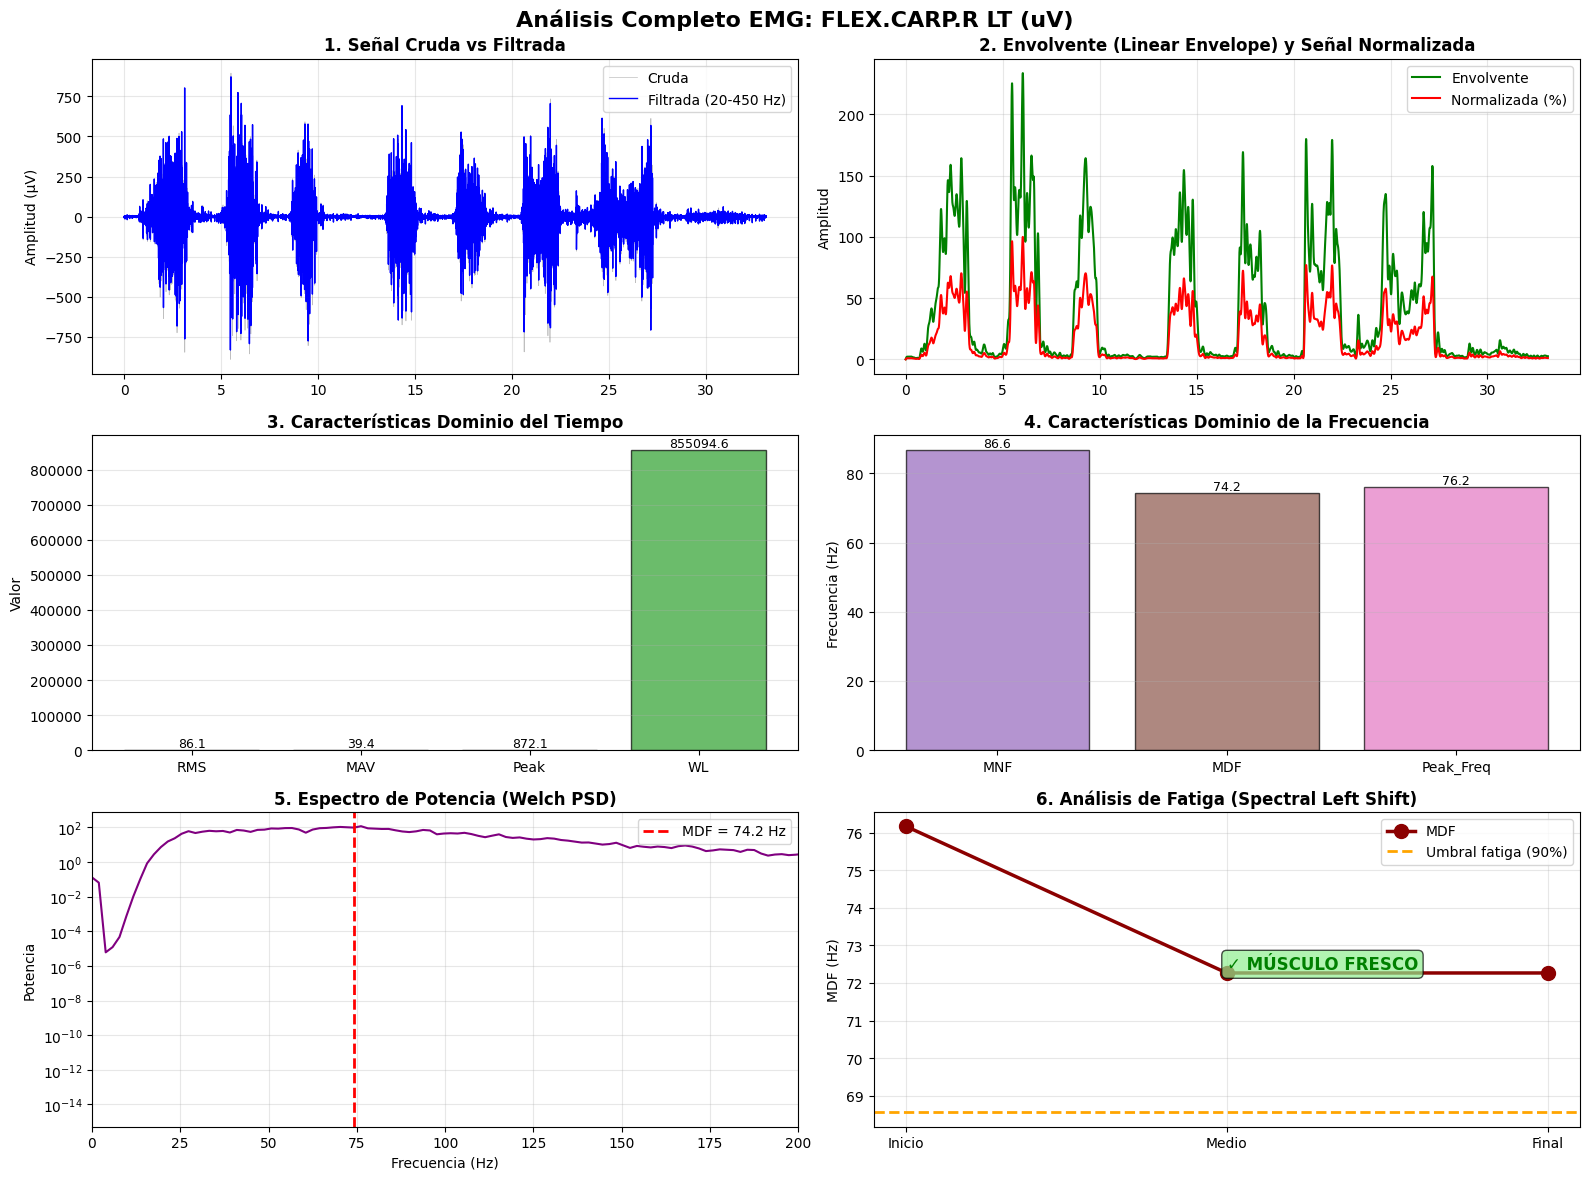


✓ Gráficos mostrados correctamente


In [9]:
# --- VISUALIZACIÓN: 6 GRÁFICOS PRINCIPALES ---
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(f'Análisis Completo EMG: {emg_col}', fontsize=16, fontweight='bold')

signals = results['processed_signals']
time_feat = results['time_domain']
freq_feat = results['frequency_domain']
fatigue = results['fatigue']

# 1. Señal Cruda y Filtrada
ax = axes[0, 0]
ax.plot(time, raw_emg, color='gray', alpha=0.5, label='Cruda', linewidth=0.5)
ax.plot(time, signals['filtered'], color='blue', label='Filtrada (20-450 Hz)', linewidth=1)
ax.set_title('1. Señal Cruda vs Filtrada', fontweight='bold')
ax.set_ylabel('Amplitud (µV)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Envolvente y Normalizada
ax = axes[0, 1]
ax.plot(time, signals['envelope'], color='green', label='Envolvente', linewidth=1.5)
ax.plot(time, signals['normalized'], color='red', label='Normalizada (%)', linewidth=1.5)
ax.set_title('2. Envolvente (Linear Envelope) y Señal Normalizada', fontweight='bold')
ax.set_ylabel('Amplitud')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Características Temporales (Bar Chart)
ax = axes[1, 0]
time_keys = ['RMS', 'MAV', 'Peak', 'WL']
time_vals = [time_feat.get(k, 0) for k in time_keys]
colors_time = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
ax.bar(time_keys, time_vals, color=colors_time, alpha=0.7, edgecolor='black')
ax.set_title('3. Características Dominio del Tiempo', fontweight='bold')
ax.set_ylabel('Valor')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(time_vals):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# 4. Características Espectrales (Bar Chart)
ax = axes[1, 1]
freq_keys = ['MNF', 'MDF', 'Peak_Freq']
freq_vals = [freq_feat.get(k, 0) for k in freq_keys]
colors_freq = ['#9467bd', '#8c564b', '#e377c2']
ax.bar(freq_keys, freq_vals, color=colors_freq, alpha=0.7, edgecolor='black')
ax.set_title('4. Características Dominio de la Frecuencia', fontweight='bold')
ax.set_ylabel('Frecuencia (Hz)')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(freq_vals):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# 5. Espectro de Potencia (Welch)
ax = axes[2, 0]
ax.semilogy(signals['f_welch'], signals['Pxx_welch'], color='purple', linewidth=1.5)
ax.axvline(freq_feat['MDF'], color='red', linestyle='--', linewidth=2, label=f"MDF = {freq_feat['MDF']:.1f} Hz")
ax.set_title('5. Espectro de Potencia (Welch PSD)', fontweight='bold')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Potencia')
ax.set_xlim(0, 200)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# 6. Análisis de Fatiga (MDF por segmento)
ax = axes[2, 1]
mdf_vals = [fatigue.get(f'MDF_Segment_{i}', 0) for i in range(3)]
seg_names = ['Inicio', 'Medio', 'Final']
ax.plot(seg_names, mdf_vals, 'o-', color='darkred', linewidth=2.5, markersize=10, label='MDF')
ax.axhline(mdf_vals[0] * FATIGUE_THRESHOLD, color='orange', linestyle='--', 
           linewidth=2, label=f'Umbral fatiga (90%)')
ax.set_title('6. Análisis de Fatiga (Spectral Left Shift)', fontweight='bold')
ax.set_ylabel('MDF (Hz)')
ax.grid(True, alpha=0.3)
ax.legend()

# Marcar si hay fatiga
if fatigue.get('Fatigue_Detected', False):
    ax.text(1, max(mdf_vals) * 0.95, '⚠ FATIGA DETECTADA', 
            fontsize=12, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
else:
    ax.text(1, max(mdf_vals) * 0.95, '✓ MÚSCULO FRESCO', 
            fontsize=12, color='green', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ Gráficos mostrados correctamente")

In [10]:
# --- RESUMEN DETALLADO EN CONSOLA ---

print("\n" + "="*80)
print("RESUMEN FINAL DEL ANÁLISIS EMG".center(80))
print("="*80)

print(f"\n INFORMACIÓN DEL ARCHIVO")
print(f"  Columna EMG:    {emg_col}")
print(f"  Duración:       {results['metadata']['duration_s']:.2f} segundos")
print(f"  Muestras:       {results['metadata']['num_samples']:,}")
print(f"  Fs (sampling):  {results['metadata']['fs']} Hz")

meta = results['metadata']
raw = results['raw_signal_stats']
print(f"\n ESTADÍSTICAS DE SEÑAL CRUDA")
print(f"  Media:          {raw['mean']:10.2f} µV")
print(f"  Desv. Est.:     {raw['std']:10.2f} µV")
print(f"  Mínimo:         {raw['min']:10.2f} µV")
print(f"  Máximo:         {raw['max']:10.2f} µV")
print(f"  Rango:          {raw['max']-raw['min']:10.2f} µV")

time_feat = results['time_domain']
print(f"\n  CARACTERÍSTICAS DOMINIO DEL TIEMPO")
print(f"  RMS:            {time_feat['RMS']:10.4f}  (Potencia)")
print(f"  MAV:            {time_feat['MAV']:10.4f}  (Amplitud media)")
print(f"  Peak:           {time_feat['Peak']:10.4f}  (Máximo absoluto)")
print(f"  WL:             {time_feat['WL']:10.1f}   (Complejidad/cambios)")
print(f"  ZC:             {time_feat['ZC']:10.0f}    (Cruces por cero)")
print(f"  IEMG:           {time_feat['IEMG']:10.2f}   (Energía total)")
print(f"  DAMV:           {time_feat['DAMV']:10.4f}  (Cambio medio)")

freq_feat = results['frequency_domain']
print(f"\n CARACTERÍSTICAS DOMINIO DE LA FRECUENCIA")
print(f"  MNF:            {freq_feat['MNF']:10.2f} Hz  (Frecuencia media)")
print(f"  MDF:            {freq_feat['MDF']:10.2f} Hz  (Frecuencia mediana) ← CLAVE PARA FATIGA")
print(f"  Peak Freq:      {freq_feat['Peak_Freq']:10.2f} Hz  (Frecuencia dominante)")
print(f"  Total Power:    {freq_feat['Total_Power']:10.2e}  (Potencia total)")
print(f"  Power <100Hz:   {freq_feat['Power_Below_100Hz_%']:10.2f} %")

env = results['envelope']
print(f"\n ENVOLVENTE Y NORMALIZACIÓN")
print(f"  Max Envelope:   {env['max']:10.2f} µV")
print(f"  Mean Envelope:  {env['mean']:10.2f} µV")
print(f"  MVC (máximo):   {env['mvc_value']:10.2f} µV  ← Usar para calibración")
print(f"  Rango normal:   0 - {env['mvc_value']:.2f} µV")

fatigue = results['fatigue']
print(f"\n  ANÁLISIS DE FATIGA MUSCULAR (Spectral Left Shift)")
print(f"  MDF Inicio:     {fatigue.get('MDF_Segment_0', 0):10.2f} Hz")
print(f"  MDF Medio:      {fatigue.get('MDF_Segment_1', 0):10.2f} Hz")
print(f"  MDF Final:      {fatigue.get('MDF_Segment_2', 0):10.2f} Hz")
print(f"  Caída MDF:      {fatigue.get('MDF_Drop_%', 0):10.2f} %")
print(f"  Umbral fatiga:  {(1 - FATIGUE_THRESHOLD)*100:10.2f} %")

if fatigue.get('Fatigue_Detected', False):
    print(f"\n   RESULTADO: FATIGA DETECTADA")
    print(f"     El MDF disminuyó más del 10%")
    print(f"     Recomendación: El operario puede estar fatigado")
else:
    print(f"\n   RESULTADO: MÚSCULO FRESCO")
    print(f"     El MDF se mantuvo relativamente estable")
    print(f"     Recomendación: El operario no muestra signos de fatiga")

print("\n" + "="*80)


                         RESUMEN FINAL DEL ANÁLISIS EMG                         

 INFORMACIÓN DEL ARCHIVO
  Columna EMG:    FLEX.CARP.R LT (uV)
  Duración:       33.11 segundos
  Muestras:       66,240
  Fs (sampling):  2000 Hz

 ESTADÍSTICAS DE SEÑAL CRUDA
  Media:                0.01 µV
  Desv. Est.:          89.04 µV
  Mínimo:            -890.54 µV
  Máximo:             895.16 µV
  Rango:             1785.69 µV

  CARACTERÍSTICAS DOMINIO DEL TIEMPO
  RMS:               86.0949  (Potencia)
  MAV:               39.3633  (Amplitud media)
  Peak:             872.0760  (Máximo absoluto)
  WL:               855094.6   (Complejidad/cambios)
  ZC:                   7947    (Cruces por cero)
  IEMG:           2607427.56   (Energía total)
  DAMV:              12.9092  (Cambio medio)

 CARACTERÍSTICAS DOMINIO DE LA FRECUENCIA
  MNF:                 86.64 Hz  (Frecuencia media)
  MDF:                 74.22 Hz  (Frecuencia mediana) ← CLAVE PARA FATIGA
  Peak Freq:           76.17 Hz  (Frecuenc

## Próximos Pasos y Aplicaciones

### Cómo usar este análisis:

**1. Para Control de Robots:**
- Utiliza `results['processed_signals']['normalized']` como entrada de control
- Rango: 0-100% (0% = reposo, 100% = máxima contracción)
- Actualiza cada 100ms para mejor respuesta temporal

**2. Para Detectar Fatiga:**
- Monitorea `MDF` en tiempo real
- Si cae más del 10%, activa alarma o aumenta asistencia del robot
- Útil para prevenir lesiones

**3. Para Análisis de Rendimiento:**
- Compara características entre diferentes usuarios
- Identifica patrones de movimiento anormal
- Evalúa efectividad de entrenamientos

**4. Para Investigación:**
- Extrae todas las características y exporta a CSV
- Compara múltiples registros
- Realiza análisis estadístico

### Archivos generados:
- `EMG_Complete_Analysis.ipynb` - Este notebook (análisis interactivo)
- `EMG_CSV.py` - Script de línea de comandos para batch processing
- `EMG.py` - Script en Tiempo real

In [11]:
# --- EXPORTAR RESULTADOS A CSV ---

import csv

# Crear un diccionario plano con todos los resultados
results_flat = {}

def flatten_dict(d, parent_key=''):
    """Convierte un diccionario anidado en uno plano."""
    for k, v in d.items():
        new_key = f"{parent_key}_{k}" if parent_key else k
        if isinstance(v, dict):
            flatten_dict(v, new_key)
        elif not isinstance(v, np.ndarray):
            results_flat[new_key] = v

flatten_dict(results)

# Guardar a CSV
output_dir = r'C:\Users\alexs\Desktop\EMG_NORAVOX\output'
os.makedirs(output_dir, exist_ok=True)

csv_file = os.path.join(output_dir, 'EMG_Analysis_Results.csv')
with open(csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Feature', 'Value'])
    for k, v in results_flat.items():
        if isinstance(v, bool):
            writer.writerow([k, str(v)])
        else:
            writer.writerow([k, v])

print(f"\n✓ Resultados exportados a: {csv_file}")
print(f"\nCaracterísticas guardadas ({len(results_flat)} total):")
for i, key in enumerate(sorted(results_flat.keys()), 1):
    print(f"  {i:2d}. {key}")


✓ Resultados exportados a: C:\Users\alexs\Desktop\EMG_NORAVOX\output\EMG_Analysis_Results.csv

Características guardadas (28 total):
   1. envelope_max
   2. envelope_mean
   3. envelope_mvc_value
   4. envelope_std
   5. fatigue_Fatigue_Detected
   6. fatigue_MDF_Drop_%
   7. fatigue_MDF_Segment_0
   8. fatigue_MDF_Segment_1
   9. fatigue_MDF_Segment_2
  10. frequency_domain_MDF
  11. frequency_domain_MNF
  12. frequency_domain_Peak_Freq
  13. frequency_domain_Power_Below_100Hz_%
  14. frequency_domain_Total_Power
  15. metadata_duration_s
  16. metadata_fs
  17. metadata_num_samples
  18. raw_signal_stats_max
  19. raw_signal_stats_mean
  20. raw_signal_stats_min
  21. raw_signal_stats_std
  22. time_domain_DAMV
  23. time_domain_IEMG
  24. time_domain_MAV
  25. time_domain_Peak
  26. time_domain_RMS
  27. time_domain_WL
  28. time_domain_ZC
